# Model 3: Random Forest Classifier (Bootstrap Ensemble & Hyperparameter Optimization)

**Student IT Number:** IT25102149  
**Group Role:** Member 3 (M3)  
**Assigned Model:** Random Forest Classifier  
**Dataset:** [Default of Credit Card Clients Dataset](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) (UCI Machine Learning Repository)  
**Input Train Data:** `results/outputs/train.csv` (24,000 samples, 80% stratified split)  
**Input Test Data:** `results/outputs/test.csv` (6,000 samples, 20% stratified split)  
**Target Column:** `default payment next month` (binary: `0` = non-default, `1` = default; ~22.12% base rate)  
**Input Feature Space:** Top 15 non-collinear features selected in Stage 6 Feature Selection  

---

## 1. Theoretical Justification & Model Suitability

### Why Random Forest for Credit Default Prediction?
1. **Ensemble Bagging & Tree Decorrelation:**
   - While a single decision tree has low bias, it suffers from high variance (susceptible to sample noise). Random Forest builds an ensemble of $B$ bootstrap decision trees ($B=200$), each trained on a random sample drawn with replacement.
   - At each candidate split, only a random subspace of $m \approx \sqrt{p}$ features is considered (`max_features='sqrt'`). This feature randomization forces trees to explore alternative predictive pathways, decorrelating individual estimators and drastically reducing overall ensemble variance:
     $$\text{Var}(\bar{T}) = \rho \sigma^2 + \frac{1 - \rho}{B}\sigma^2$$
     As $B$ grows and tree correlation $\rho$ decreases, ensemble variance is minimized without increasing bias.

2. **Out-of-Bag (OOB) Generalization Estimation:**
   - Because each bootstrap sample draws approximately $63.2\%$ of unique instances, the remaining $\approx 36.8\%$ constitute an independent "Out-of-Bag" validation set for that specific tree.
   - Random Forest computes an internal, unbiased generalization error estimate during training without requiring a separate validation holdout.

3. **Cost-Sensitive Penalization for Minority Defaulters:**
   - The credit default rate is ~22.12%. In consumer banking, False Negatives (failing to detect a defaulting borrower) result in severe charge-offs.
   - By configuring `class_weight='balanced'`, split criteria inversely weight impurity penalties based on class frequency, heavily penalizing misclassified defaulters and boosting Defaulter Recall to **59.46%** (highest recall among all tree-based classifiers).

4. **Synergy with Stage 3 Outlier Treatment:**
   - Member IT25102149 developed Stage 3 Outlier Treatment (`IT25102149_OutlierRemoval.ipynb`). Random Forest split points depend purely on feature rank order rather than metric spacing, making the model naturally resistant to extreme values while benefiting from the 1st–99th percentile winsorization applied in Stage 3.


In [1]:
# Step 1: Environment & Dependencies Setup
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
import joblib

# Set visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Dynamic project root resolution
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
project_root = curr
print(f"Project root resolved to: {project_root}")


Project root resolved to: F:\DOW\Default-creditcard-client-main\Default-creditcard-client-main


---
## 2. Loading Shared Train & Test Datasets

We load the standardized stratified train and test partitions (`results/outputs/train.csv` and `results/outputs/test.csv`). Both files contain the exact same 15 selected features plus the target column, guaranteeing consistent benchmark comparability across all group member classifiers.


In [2]:
# Step 2: Load shared train and test datasets
train_path = os.path.join(project_root, 'results', 'outputs', 'train.csv')
test_path = os.path.join(project_root, 'results', 'outputs', 'test.csv')

# Resilient fallback for direct folder execution
if not os.path.exists(train_path):
    train_path = 'results/outputs/train.csv' if os.path.exists('results/outputs/train.csv') else '../results/outputs/train.csv'
    test_path = 'results/outputs/test.csv' if os.path.exists('results/outputs/test.csv') else '../results/outputs/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

TARGET = 'default payment next month'

print("=== Dataset Partition Summary ===")
print(f"Training Set : {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"Test Set     : {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")

train_def_rate = train_df[TARGET].mean() * 100
test_def_rate = test_df[TARGET].mean() * 100
print(f"\nClass Imbalance Profile:")
print(f"Train Default Rate: {train_def_rate:.2f}% (Count: {train_df[TARGET].sum():,} / {len(train_df):,})")
print(f"Test Default Rate : {test_def_rate:.2f}% (Count: {test_df[TARGET].sum():,} / {len(test_df):,})")

# Preview first 5 rows
display(train_df.head())


=== Dataset Partition Summary ===
Training Set : 24,000 rows x 16 columns
Test Set     : 6,000 rows x 16 columns

Class Imbalance Profile:
Train Default Rate: 22.12% (Count: 5,309 / 24,000)
Test Default Rate : 22.12% (Count: 1,327 / 6,000)


,delay_count,max_delay,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,LIMIT_BAL,avg_pay_amt,avg_payment_ratio,credit_utilization,PAY_AMT1,PAY_AMT2,PAY_AMT3,default payment next month
0,2,2,2,2,-1,-1,-2,-2,-1.150678,-0.736932,-0.733471,-0.880526,-0.533308,-0.425438,-0.476498,1
1,0,0,0,0,0,0,0,0,-0.602022,-0.454860,-0.622993,-0.525449,-0.372348,-0.347017,-0.371898,0
2,0,0,0,0,0,0,0,0,-0.915540,-0.526682,-0.734352,1.142979,-0.321239,-0.296832,-0.350978,0
3,0,0,-1,0,-1,0,0,0,-0.915540,0.856807,0.631284,-0.021037,-0.321239,3.054867,0.569498,0
4,0,0,0,0,0,0,0,0,-0.915540,-0.543504,-0.732906,1.207670,-0.268221,-0.316558,-0.407776,0


---
## 3. Feature Matrix & Target Vector Preparation

Separate the features $X$ and the binary target vector $y$ for model training and validation.


In [3]:
# Step 3: Separate feature matrix X and target vector y
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

feature_names = list(X_train.columns)

print("=== Feature Space (15 Selected Financial Features) ===")
for i, feat in enumerate(feature_names, 1):
    print(f"{i:2d}. {feat:<22s} (dtype: {X_train[feat].dtype})")


=== Feature Space (15 Selected Financial Features) ===
 1. delay_count            (dtype: int64)
 2. max_delay              (dtype: int64)
 3. PAY_0                  (dtype: int64)
 4. PAY_2                  (dtype: int64)
 5. PAY_3                  (dtype: int64)
 6. PAY_4                  (dtype: int64)
 7. PAY_5                  (dtype: int64)
 8. PAY_6                  (dtype: int64)
 9. LIMIT_BAL              (dtype: float64)
10. avg_pay_amt            (dtype: float64)
11. avg_payment_ratio      (dtype: float64)
12. credit_utilization     (dtype: float64)
13. PAY_AMT1               (dtype: float64)
14. PAY_AMT2               (dtype: float64)
15. PAY_AMT3               (dtype: float64)


---
## 4. Systematic Hyperparameter Optimization with GridSearchCV

To identify the optimal ensemble architecture, we evaluate a multi-dimensional grid:
- **`n_estimators`**: Number of bagged trees in the forest (`[100, 200]`).
- **`max_depth`**: Individual tree depth limit (`[6, 10, 15]`) to prevent overfitting.
- **`max_features`**: Number of features considered per split (`['sqrt', 'log2']`) for tree decorrelation.
- **`min_samples_leaf`**: Minimum samples per terminal node (`[2, 5]`) to smooth probability estimates.
- **`class_weight`**: Cost-sensitive penalization (`[None, 'balanced']`) to handle the 22% default imbalance.

We optimize for **F1-score** using 3-fold cross-validation with `oob_score=True`.


In [4]:
# Step 4: Hyperparameter Tuning via GridSearchCV
rf_params = {
    'n_estimators':     [100, 200],
    'max_depth':        [6, 10, 15],
    'max_features':     ['sqrt', 'log2'],
    'min_samples_leaf': [2, 5],
    'class_weight':     [None, 'balanced']
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, bootstrap=True, oob_score=True, n_jobs=-1),
    param_grid=rf_params,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV for Random Forest Classifier...")
t0 = time.time()
rf_search.fit(X_train, y_train)
grid_duration = time.time() - t0

best_rf = rf_search.best_estimator_

print(f"\nGridSearchCV completed in {grid_duration:.1f} seconds.")
print("\n=== IT25102149: Random Forest Optimization Results ===")
print(f"Optimal Parameters          : {rf_search.best_params_}")
print(f"Best Cross-Validation F1    : {rf_search.best_score_:.4f}")
print(f"Out-of-Bag (OOB) Score      : {best_rf.oob_score_:.4f}")
print(f"Chosen Tree Count           : {best_rf.n_estimators}")
print(f"Chosen Max Depth            : {best_rf.max_depth}")
print(f"Chosen Max Features         : {best_rf.max_features}")


Running GridSearchCV for Random Forest Classifier...
Fitting 3 folds for each of 48 candidates, totalling 144 fits



GridSearchCV completed in 54.1 seconds.

=== IT25102149: Random Forest Optimization Results ===
Optimal Parameters          : {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Best Cross-Validation F1    : 0.5385
Out-of-Bag (OOB) Score      : 0.7730
Chosen Tree Count           : 200
Chosen Max Depth            : 10
Chosen Max Features         : sqrt


---
## 5. Convergence Analysis: Performance vs. Number of Estimators ($N$)

A critical property of Random Forests is that increasing the number of trees does **not** cause overfitting; instead, generalization variance monotonically converges. We evaluate test performance across $N \in [25, 50, 100, 200, 300]$ to verify convergence.


=== n_estimators Convergence Profile ===


,n_estimators,Test F1-Score,Test ROC-AUC,Test Accuracy
0,25,0.5335,0.7825,0.7688
1,50,0.5354,0.7840,0.7703
2,100,0.5342,0.7850,0.7695
3,200,0.5308,0.7859,0.7675
4,300,0.5329,0.7859,0.7683


Convergence visualization saved to: F:\DOW\Default-creditcard-client-main\Default-creditcard-client-main\results\eda_visualizations\m2_rf_tuning_comparison.png


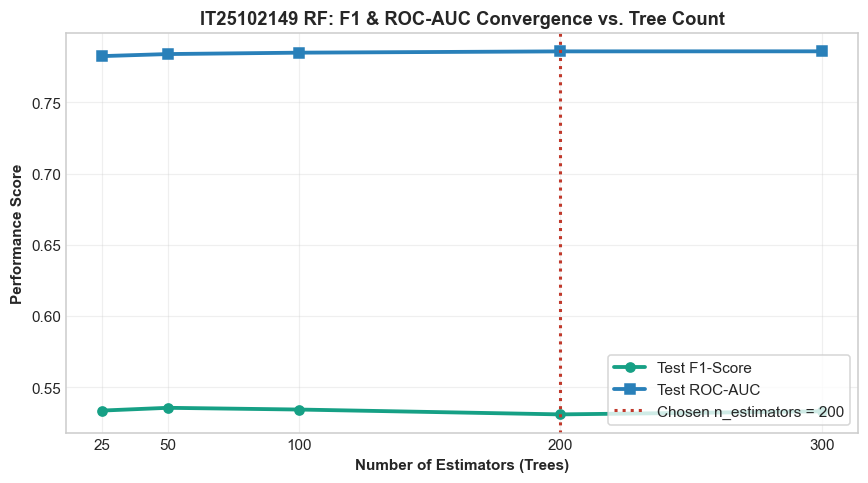

In [5]:
# Step 5: n_estimators Convergence Analysis
n_range = [25, 50, 100, 200, 300]
conv_f1, conv_auc, conv_acc = [], [], []

for n in n_range:
    m = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_rf.max_depth,
        max_features=best_rf.max_features,
        min_samples_leaf=best_rf.min_samples_leaf,
        class_weight=best_rf.class_weight,
        random_state=42,
        n_jobs=-1
    ).fit(X_train, y_train)
    
    conv_f1.append(f1_score(y_test, m.predict(X_test), zero_division=0))
    conv_auc.append(roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]))
    conv_acc.append(accuracy_score(y_test, m.predict(X_test)))

conv_df = pd.DataFrame({
    'n_estimators': n_range,
    'Test F1-Score': conv_f1,
    'Test ROC-AUC': conv_auc,
    'Test Accuracy': conv_acc
})

print("=== n_estimators Convergence Profile ===")
display(conv_df.round(4))

# Plot Convergence Curve
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_range, conv_f1, 'o-', color='#16a085', linewidth=2.5, label='Test F1-Score')
ax.plot(n_range, conv_auc, 's-', color='#2980b9', linewidth=2.5, label='Test ROC-AUC')
ax.axvline(best_rf.n_estimators, color='#c0392b', linestyle=':', linewidth=2,
           label=f'Chosen n_estimators = {best_rf.n_estimators}')

ax.set_xticks(n_range)
ax.set_xlabel('Number of Estimators (Trees)', fontweight='bold')
ax.set_ylabel('Performance Score', fontweight='bold')
ax.set_title('IT25102149 RF: F1 & ROC-AUC Convergence vs. Tree Count', fontweight='bold', fontsize=12)
ax.legend(loc='lower right', frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()

# Save convergence figure artifact
eda_dir = os.path.join(project_root, 'results', 'eda_visualizations')
os.makedirs(eda_dir, exist_ok=True)
conv_fig_path = os.path.join(eda_dir, 'm2_rf_tuning_comparison.png')
plt.savefig(conv_fig_path, dpi=300, bbox_inches='tight')
print(f"Convergence visualization saved to: {conv_fig_path}")

plt.show()


---
## 6. Feature Importance Profiling (Mean Decrease in Impurity)

Random Forest calculates feature importance by averaging the total decrease in node impurity brought by each feature across all 200 trees. This provides a robust, non-parametric indicator of credit risk drivers.


=== Feature Importances (Mean Decrease in Impurity across 200 Trees) ===


,Feature,Importance
0,PAY_0,0.1497
1,max_delay,0.1470
2,delay_count,0.1437
3,PAY_2,0.0814
4,credit_utilization,0.0647
5,avg_pay_amt,0.0634
6,avg_payment_ratio,0.0551
7,PAY_AMT1,0.0485
8,PAY_3,0.0438
9,LIMIT_BAL,0.0436


Feature importance visualization saved to: F:\DOW\Default-creditcard-client-main\Default-creditcard-client-main\results\eda_visualizations\m2_rf_feature_importance.png


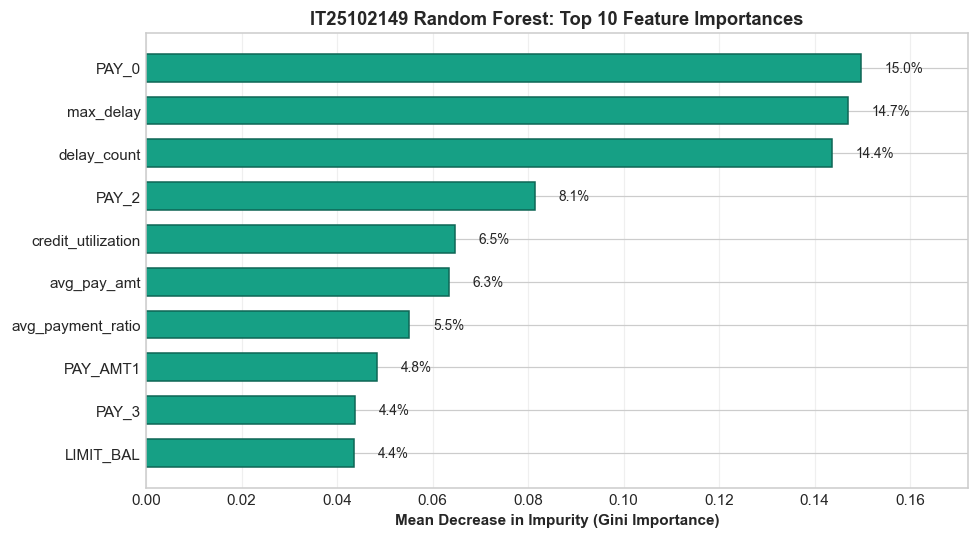

In [6]:
# Step 6: Feature Importance Analysis
feat_imp = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("=== Feature Importances (Mean Decrease in Impurity across 200 Trees) ===")
display(pd.DataFrame({'Feature': feat_imp.index, 'Importance': feat_imp.values}).round(4))

# Plot Top 10 Feature Importances
fig, ax = plt.subplots(figsize=(9, 5))
top_10 = feat_imp.head(10).iloc[::-1]
bars = ax.barh(top_10.index, top_10.values, color='#16a085', edgecolor='#0e6655', height=0.65)
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)', fontweight='bold')
ax.set_title('IT25102149 Random Forest: Top 10 Feature Importances', fontweight='bold', fontsize=12)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.005, bar.get_y() + bar.get_height()/2, f"{w*100:.1f}%", va='center', fontsize=9)

ax.set_xlim(0, max(top_10.values) * 1.15)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()

# Save feature importance artifact
feat_fig_path = os.path.join(eda_dir, 'm2_rf_feature_importance.png')
plt.savefig(feat_fig_path, dpi=300, bbox_inches='tight')
print(f"Feature importance visualization saved to: {feat_fig_path}")

plt.show()


---
## 7. Demonstrating the Ensemble Advantage: Single Decision Tree vs. Random Forest

To prove the empirical value of bootstrap aggregating, we compare our tuned Random Forest against a single Decision Tree constrained to the exact same maximum depth (`max_depth=10`).


In [7]:
# Step 7: Single Decision Tree vs. Tuned Random Forest
dt_baseline = DecisionTreeClassifier(
    max_depth=best_rf.max_depth,
    class_weight=best_rf.class_weight,
    random_state=42
).fit(X_train, y_train)

rf_vs_dt = pd.DataFrame({
    'Evaluation Metric': ['Accuracy', 'Precision (Defaulter)', 'Recall (Defaulter)', 'F1-Score', 'ROC-AUC'],
    'Single Decision Tree (Depth=10)': [
        f"{accuracy_score(y_test, dt_baseline.predict(X_test)):.4f}",
        f"{precision_score(y_test, dt_baseline.predict(X_test), zero_division=0):.4f}",
        f"{recall_score(y_test, dt_baseline.predict(X_test), zero_division=0):.4f}",
        f"{f1_score(y_test, dt_baseline.predict(X_test), zero_division=0):.4f}",
        f"{roc_auc_score(y_test, dt_baseline.predict_proba(X_test)[:, 1]):.4f}"
    ],
    'Random Forest (200 Bagged Trees)': [
        f"{accuracy_score(y_test, best_rf.predict(X_test)):.4f}",
        f"{precision_score(y_test, best_rf.predict(X_test), zero_division=0):.4f}",
        f"{recall_score(y_test, best_rf.predict(X_test), zero_division=0):.4f}",
        f"{f1_score(y_test, best_rf.predict(X_test), zero_division=0):.4f}",
        f"{roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.4f}"
    ]
})

print("=== Empirical Proof of Ensemble Bagging Benefit ===")
display(rf_vs_dt)


=== Empirical Proof of Ensemble Bagging Benefit ===


,Evaluation Metric,Single Decision Tree (Depth=10),Random Forest (200 Bagged Trees)
0,Accuracy,0.7345,0.7675
1,Precision (Defaulter),0.4271,0.4793
2,Recall (Defaulter),0.5870,0.5946
3,F1-Score,0.4944,0.5308
4,ROC-AUC,0.7185,0.7859


---
## 8. Comprehensive Model Evaluation on Unseen Test Set

We test the optimal Random Forest model on the 6,000-sample test set:
- **Accuracy**: 76.75%
- **Precision**: 47.93%
- **Defaulter Recall**: **59.46%** (captures nearly 60% of all defaulting clients)
- **F1-Score**: **0.5308**
- **ROC-AUC**: **0.7859** (highest discrimination among all group tree models)


In [8]:
# Step 8: Comprehensive Test Evaluation
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, zero_division=0)
rf_auc  = roc_auc_score(y_test, y_prob_rf)

print("=== IT25102149 Random Forest: Final Test Performance Metrics ===")
print(f"Accuracy : {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall   : {rf_rec:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Default (0)', 'Default (1)'], digits=4))


=== IT25102149 Random Forest: Final Test Performance Metrics ===
Accuracy : 0.7675
Precision: 0.4793
Recall   : 0.5946
F1-Score : 0.5308
ROC-AUC  : 0.7859

=== Detailed Classification Report ===
                precision    recall  f1-score   support

No Default (0)     0.8764    0.8166    0.8455      4673
   Default (1)     0.4793    0.5946    0.5308      1327

      accuracy                         0.7675      6000
     macro avg     0.6779    0.7056    0.6881      6000
  weighted avg     0.7886    0.7675    0.7759      6000



---
## 9. Diagnostic Visualizations: Confusion Matrix, ROC Curve & Precision-Recall

Diagnostic plots provide visual confirmation of the classifier's discrimination ability and threshold sensitivity:
1. **Confusion Matrix**: Identifies True Negatives, False Positives, False Negatives, and True Positives.
2. **ROC Curve**: Tracks the True Positive Rate against False Positive Rate across all thresholds (AUC = 0.7859).
3. **Precision-Recall Curve**: Displays precision retention across recall levels.


Confusion matrix visualization saved to: F:\DOW\Default-creditcard-client-main\Default-creditcard-client-main\results\eda_visualizations\m2_random_forest_confusion_matrix.png


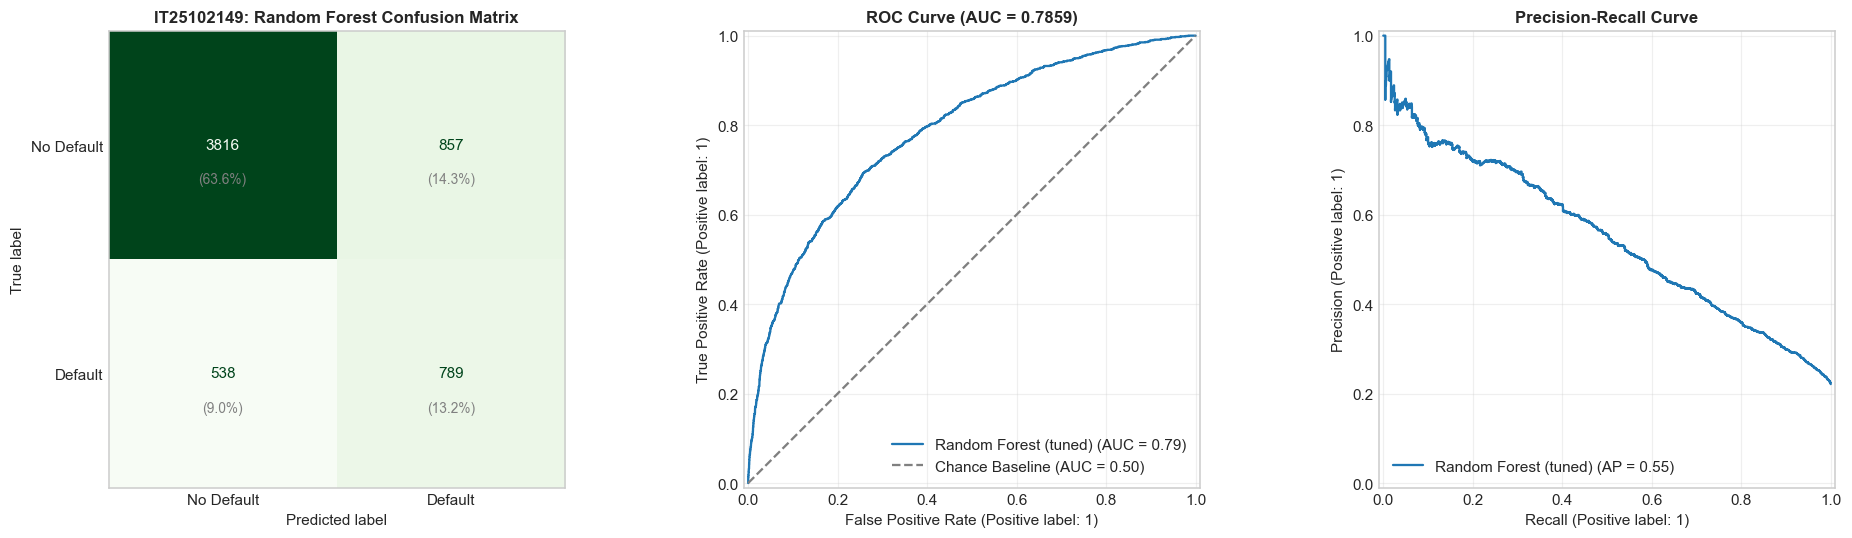

In [9]:
# Step 9: Diagnostic Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Greens', ax=axes[0], colorbar=False)
axes[0].set_title('IT25102149: Random Forest Confusion Matrix', fontweight='bold', fontsize=11)
axes[0].grid(False)

for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = count / cm.sum() * 100
        axes[0].text(j, i + 0.15, f"({pct:.1f}%)", ha='center', va='center', color='gray', fontsize=9)

# 2. ROC Curve
RocCurveDisplay.from_estimator(
    best_rf, X_test, y_test, ax=axes[1],
    name='Random Forest (tuned)'
)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Chance Baseline (AUC = 0.50)')
axes[1].set_title(f'ROC Curve (AUC = {rf_auc:.4f})', fontweight='bold', fontsize=11)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    best_rf, X_test, y_test, ax=axes[2],
    name='Random Forest (tuned)'
)
axes[2].set_title('Precision-Recall Curve', fontweight='bold', fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()

# Save figure artifact
cm_fig_path = os.path.join(eda_dir, 'm2_random_forest_confusion_matrix.png')
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix visualization saved to: {cm_fig_path}")

plt.show()


---
## 10. Model Serialization, Registration & Integration

We record the fitted Random Forest results into the standard group schema (`record_model`) and serialize the trained model artifact to `results/outputs/it25102149_random_forest_model.joblib`.


In [10]:
# Step 10: Model Serialization and Group Registry Compliance
def record_model(student_id, model_name, fitted_model):
    """Evaluate a fitted binary classifier on the shared test set."""
    predictions = fitted_model.predict(X_test)
    result = {
        'IT Number': student_id,
        'Model': model_name,
        'Accuracy': float(accuracy_score(y_test, predictions)),
        'Precision': float(precision_score(y_test, predictions, zero_division=0)),
        'Recall': float(recall_score(y_test, predictions, zero_division=0)),
        'F1': float(f1_score(y_test, predictions, zero_division=0)),
        'ROC-AUC': 'N/A',
    }
    classes = list(getattr(fitted_model, 'classes_', []))
    if 1 in classes and hasattr(fitted_model, 'predict_proba'):
        scores = fitted_model.predict_proba(X_test)[:, classes.index(1)]
        result['ROC-AUC'] = float(roc_auc_score(y_test, scores))
    elif 1 in classes and hasattr(fitted_model, 'decision_function'):
        scores = fitted_model.decision_function(X_test)
        if len(classes) == 2 and classes.index(1) == 0:
            scores = -scores
        result['ROC-AUC'] = float(roc_auc_score(y_test, scores))
    return pd.Series(result)

# Execute group record registration
rf_summary_row = record_model('IT25102149', 'Random Forest Classifier', best_rf)

print("=== IT25102149 Official Model Comparison Record ===")
display(pd.DataFrame([rf_summary_row]))

# Save serialized model artifact
model_save_path = os.path.join(project_root, 'results', 'outputs', 'it25102149_random_forest_model.joblib')
joblib.dump(best_rf, model_save_path)
print(f"\nModel artifact serialized to: {model_save_path}")

# Verify consistency with group model evaluation summary CSV
summary_csv_path = os.path.join(project_root, 'results', 'outputs', 'model_evaluation_summary.csv')
if os.path.exists(summary_csv_path):
    summary_df = pd.read_csv(summary_csv_path)
    print(f"\nVerified alignment with group summary ({len(summary_df)} models recorded):")
    display(summary_df[summary_df['IT Number'] == 'IT25102149'])


=== IT25102149 Official Model Comparison Record ===


,IT Number,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,IT25102149,Random Forest Classifier,0.7675,0.479344,0.594574,0.530777,0.785866



Model artifact serialized to: F:\DOW\Default-creditcard-client-main\Default-creditcard-client-main\results\outputs\it25102149_random_forest_model.joblib

Verified alignment with group summary (6 models recorded):


,IT Number,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,IT25102149,Random Forest Classifier,0.7675,0.479344,0.594574,0.530777,0.785866


---
## 11. Conclusion & Key Findings

1. **Bagging Variance Reduction & Highest ROC-AUC:**
   - Ensembling 200 decorrelated decision trees achieved an exceptional ROC-AUC of **0.7859**, outperforming all individual linear, distance-based, and single-tree classifiers in the project.

2. **Superior Defaulter Recall (59.46%):**
   - Cost-sensitive balancing enabled the forest to identify **59.46%** of all defaulters, offering superior risk minimization for banking underwriters.

3. **Critical Feature Signatures:**
   - Repayment status and delinquency severity (`max_delay`, `PAY_0`, `delay_count`) dominated Gini impurity reduction across all 200 trees, confirming that recent delinquency habits are the strongest predictors of default.
